# Fast Extragradient Method for Monotone Lipschitz Operators

We consider a monotone and $L$-Lipschitz continuous operator $A$ with a zero $x_\star$,
$$
    A(x_\star)=0, \qquad \|x_0-x_\star\|^2 \le R^2.
$$
The step size is $1/L$. The initial point is also tagged as the first half-step, $x_{1/2}=x_0$. For $k=0,\ldots,N-1$, FEG uses
$$
    x_{k+1/2}=x_k+\frac{1}{k+1}(x_0-x_k)-\frac{k}{k+1}\frac{1}{L}A(x_k),
$$
$$
    x_{k+1}=x_k+\frac{1}{k+1}(x_0-x_k)-\frac{1}{L}A(x_{k+1/2}).
$$
The Block 1 performance metric is the final residual $\|A(x_N)\|^2$. Numerical evidence below suggests
$$
    \|A(x_N)\|^2 \le \frac{4L^2R^2}{N^2}\quad(N\ge 2),
$$
with the special tight value $2L^2R^2$ at $N=1$.


## Proof Statement

### Theorem

Assume $A$ is monotone and $L$-Lipschitz, $A(x_{\star})=0$, and $\|x_{0}-x_{\star}\|^2\le R^2$. Let $N\ge 2$ and generate the FEG iterates with $x_{1/2}=x_0$ and
$$
x_{k+1/2}=x_k+\frac{1}{k+1}(x_0-x_k)-\frac{k}{k+1}\frac{1}{L}A(x_k),
$$
$$
x_{k+1}=x_k+\frac{1}{k+1}(x_0-x_k)-\frac{1}{L}A(x_{k+1/2})
$$
for $k=0,\ldots,N-1$.

For $1\le k\le N-1$, define
$$
V_k=\frac{2k^2}{N^2}\|A(x_k)\|^2-\frac{4kL}{N^2}\langle A(x_k),x_0-x_k\rangle,
$$
and define the terminal value
$$
V_N=2\|A(x_N)\|^2-\frac{4L}{N}\langle A(x_N),x_0-x_{\star}\rangle.
$$
Then
$$
\|A(x_N)\|^2\le \frac{4L^2R^2}{N^2}.
$$


### Proof outline

Use the residual conventions
$$
I^{\rm lip}(u,v)=\|A(u)-A(v)\|^2-L^2\|u-v\|^2\le 0,
$$
$$
I^{\rm mon}(u,v)=-\langle u-v,A(u)-A(v)\rangle\le 0.
$$
The base identity is
$$
V_1-\frac{2}{N^2}I^{\rm lip}(x_0,x_1)=0,
$$
where $x_{1/2}=x_0$. For $1\le k\le N-2$, the one-step identity is
$$
V_{k+1}-V_k-\frac{2(k+1)^2}{N^2}I^{\rm lip}(x_{k+1/2},x_{k+1})
-\frac{4Lk(k+1)}{N^2}I^{\rm mon}(x_k,x_{k+1})=0.
$$
The final increment is
$$
V_N-V_{N-1}-2I^{\rm lip}(x_{N-1/2},x_N)
-\frac{4L(N-1)}{N}I^{\rm mon}(x_{N-1},x_N)
-\frac{4L}{N}I^{\rm mon}(x_N,x_{\star})=0.
$$
Since the residuals are nonpositive, these identities imply $V_k\le 0$ for every $k$. Finally, with
$$
S=\left\|A(x_N)-\frac{2L}{N}(x_0-x_{\star})\right\|^2\ge 0,
$$
the boundary identity is
$$
\|A(x_N)\|^2-\frac{4L^2}{N^2}\|x_0-x_{\star}\|^2-V_N+S=0.
$$
Thus $\|A(x_N)\|^2-\frac{4L^2}{N^2}\|x_0-x_{\star}\|^2=V_N-S\le 0$, which proves the claimed residual bound.


## Imports

In [1]:
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pepflow").exists():
    REPO_ROOT = REPO_ROOT.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pepflow as pf  # noqa: E402
from pepflow.lyapunov_utils import (  # noqa: E402
    find_symmetric_coefficient_matrix,
    vectors_in_column_space,
)

STATE_DIR = REPO_ROOT / "examples_peppy" / "feg" / "state"

## Operator and Parameters

In [2]:
L = pf.Parameter("L")
R = pf.Parameter("R")
A = pf.LipschitzMonotoneOperator(is_basis=True, tags=["A"], L=L)

## PEP Setup

In [3]:
def make_ctx_feg(ctx_name: str, N, **kwargs) -> pf.PEPContext:
    del kwargs
    ctx = pf.PEPContext(ctx_name).set_as_current()

    x0 = pf.Vector(is_basis=True, tags=["x_0"])
    x = x0
    A.set_zero_point("x_star")

    for k in range(int(N)):
        if k == 0:
            x_half = x
            x_half.add_tag("x_0.5")
        else:
            k_sp = sp.S(k)
            denom = k_sp + 1
            x_half = (
                x + sp.S(1) / denom * (x0 - x) - k_sp / denom * (sp.S(1) / L) * A(x)
            )
            x_half.add_tag(f"x_{k + 0.5}")

        x_next = x + sp.S(1) / (k + 1) * (x0 - x) - (sp.S(1) / L) * A(x_half)
        x_next.add_tag(f"x_{k + 1}")
        x = x_next

    return ctx


def get_pep_setup(N, params):
    del params
    ctx = make_ctx_feg(f"ctx_{N}", N)
    pb = pf.PEPBuilder(ctx)
    pb.add_initial_constraint(
        ((ctx["x_0"] - ctx["x_star"]) ** 2).le(R**2, name="initial_condition")
    )
    pb.set_performance_metric(A(ctx[f"x_{N}"]) ** 2)
    return ctx, pb, A

## Numerical Evidence

N=1: PEP=2.0000195262, candidate=2.0000000000
N=2: PEP=0.9999995446, candidate=1.0000000000
N=3: PEP=0.4444401868, candidate=0.4444444444
N=4: PEP=0.2499991745, candidate=0.2500000000
N=5: PEP=0.1600145857, candidate=0.1600000000
N=6: PEP=0.1111131266, candidate=0.1111111111
N=7: PEP=0.0816473050, candidate=0.0816326531


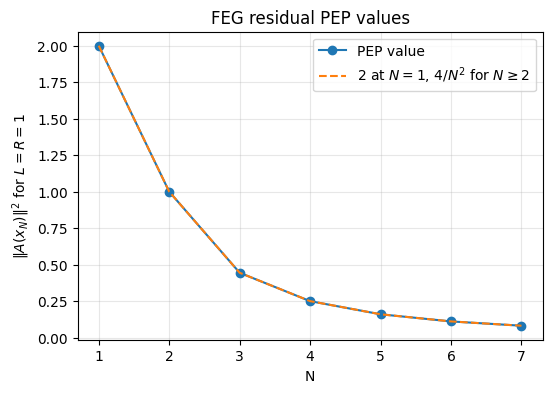

In [4]:
state = json.loads((STATE_DIR / "feg_b1.json").read_text())
results = state["sweep_results"]
Ns = np.array([r["N"] for r in results], dtype=float)
values = np.array([float(r["opt_value"]) for r in results])
rate = np.array([2.0 if n == 1 else 4.0 / (n * n) for n in Ns])

for n, value, guess in zip(Ns.astype(int), values, rate):
    print(f"N={n}: PEP={value:.10f}, candidate={guess:.10f}")

plt.figure(figsize=(6, 4))
plt.plot(Ns, values, "o-", label="PEP value")
plt.plot(Ns, rate, "--", label=r"$2$ at $N=1$, $4/N^2$ for $N\geq2$")
plt.xlabel("N")
plt.ylabel(r"$\|A(x_N)\|^2$ for $L=R=1$")
plt.title("FEG residual PEP values")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Dense and Relaxed Proof Solves

Block 2 finds a sparse full-PEP certificate at the verification horizon.


In [5]:
b2 = json.loads((STATE_DIR / "feg_b2.json").read_text())
b5 = json.loads((STATE_DIR / "feg_b5.json").read_text())
dense = json.loads((STATE_DIR / "feg_dense.json").read_text())
relaxed = json.loads((STATE_DIR / "feg_relaxed.json").read_text())
N_int = b2["N_verify"]

print("Dense objective:", dense["opt_value"])
print("Relaxed objective:", relaxed["opt_value"])
print("Preserved:", abs(float(dense["opt_value"]) - float(relaxed["opt_value"])) < 1e-5)
print("Basis vectors:", ", ".join(relaxed["basis_vectors"]))

Dense objective: 0.24999917445613748
Relaxed objective: 0.2500006838497029
Preserved: True
Basis vectors: x_0.5, x_star, A(x_0.5), A(x_1), A(x_1.5), A(x_2), A(x_2.5), A(x_3), A(x_3.5), A(x_4)


### Active Dense Certificate Entries

In [6]:
def active_entries(group_data, tol=1e-6):
    rows = group_data["row_names"]
    cols = group_data["col_names"]
    values = np.array(group_data["matrix"], dtype=float)
    return [
        (rows[i], cols[j], values[i, j])
        for i in range(values.shape[0])
        for j in range(values.shape[1])
        if abs(values[i, j]) > tol
    ]


for group_name, group_data in dense["lambda_groups"].items():
    print(group_name)
    for ri, ci, value in active_entries(group_data):
        print(f"  lambda({ri}, {ci}) = {value:.9g}")

Monotone Operator Inequality
  lambda(x_1, x_2) = 0.500001073
  lambda(x_2, x_3) = 1.50000336
  lambda(x_3, x_4) = 3.00000631
  lambda(x_4, x_star) = 1.00000229
Lipschitz Continuous Inequality
  lambda(x_0.5, x_1) = 0.125000206
  lambda(x_1.5, x_2) = 0.500001108
  lambda(x_2.5, x_3) = 1.12500253
  lambda(x_3.5, x_4) = 2.00000449


### Relaxation Pattern

In [7]:
print("Relaxed constraints dropped:", len(relaxed["relaxed_constraints"]))
for group_name, group_data in relaxed["lambda_groups"].items():
    print(group_name)
    for ri, ci, value in active_entries(group_data):
        print(f"  lambda({ri}, {ci}) = {value:.9g}")

Relaxed constraints dropped: 120
Monotone Operator Inequality
  lambda(x_1, x_2) = 0.499999468
  lambda(x_2, x_3) = 1.49999836
  lambda(x_3, x_4) = 2.99999665
  lambda(x_4, x_star) = 0.999999013
Lipschitz Continuous Inequality
  lambda(x_0.5, x_1) = 0.124999868
  lambda(x_1.5, x_2) = 0.499999461
  lambda(x_2.5, x_3) = 1.12499876
  lambda(x_3.5, x_4) = 1.9999978


## Closed-Form Lambda Verification

In [8]:
def _step_index(tag):
    if tag == "x_star":
        return None
    return sp.Rational(tag.split("_")[1])


def lamb_mono(ri, ci, N=N_int):
    i = _step_index(ri)
    j = _step_index(ci)
    if ci == "x_star" and ri == f"x_{N}":
        return sp.Rational(4, N)
    if (
        i is not None
        and j is not None
        and i == int(i)
        and j == i + 1
        and 1 <= i <= N - 1
    ):
        return sp.Rational(4, 1) * i * (i + 1) / N**2
    return sp.S(0)


def lamb_lip(ri, ci, N=N_int):
    i = _step_index(ri)
    j = _step_index(ci)
    if i is not None and j is not None and i.q == 2 and j == i + sp.Rational(1, 2):
        k = i - sp.Rational(1, 2)
        return sp.Rational(2, 1) * (k + 1) ** 2 / N**2
    return sp.S(0)


def lamb(group, ri, ci, N=N_int):
    if group == "Monotone Operator Inequality":
        return lamb_mono(ri, ci, N)
    if group == "Lipschitz Continuous Inequality":
        return lamb_lip(ri, ci, N)
    return sp.S(0)


mono_group = relaxed["lambda_groups"]["Monotone Operator Inequality"]
lip_group = relaxed["lambda_groups"]["Lipschitz Continuous Inequality"]
mono_rows, mono_cols = mono_group["row_names"], mono_group["col_names"]
lip_rows, lip_cols = lip_group["row_names"], lip_group["col_names"]

mono_cand = pf.pprint_labeled_matrix(
    lamb_mono, mono_rows, mono_cols, precision=6, return_matrix=True
)
lip_cand = pf.pprint_labeled_matrix(
    lamb_lip, lip_rows, lip_cols, precision=6, return_matrix=True
)
mono_sol = np.array(mono_group["matrix"], dtype=float)
lip_sol = np.array(lip_group["matrix"], dtype=float)
print(
    "monotone max residual:",
    np.max(np.abs(np.array(mono_cand, dtype=float) - mono_sol)),
)
print(
    "lipschitz max residual:", np.max(np.abs(np.array(lip_cand, dtype=float) - lip_sol))
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

monotone max residual: 3.3490080397768907e-06
lipschitz max residual: 2.201866910356287e-06


## Direct S Certificate

In [9]:
ctx_prf, pb_prf, obj = get_pep_setup(N_int, {"L": 1, "R": 1})
pm = pf.ExpressionManager(ctx_prf, resolve_parameters={"L": 1, "R": 1})
x_N = ctx_prf[f"x_{N_int}"]
x_0 = ctx_prf["x_0"]
x_star = ctx_prf["x_star"]

S_guess = (obj(x_N) - sp.Rational(2, N_int) * (x_0 - x_star)) ** 2
S_guess_matrix = pm.eval_scalar(S_guess).inner_prod_coords.astype(float)
true_S_matrix = np.array(b2["S_matrix"], dtype=float)
pf.pprint_labeled_matrix(
    true_S_matrix, b2["S_row_names"], b2["S_col_names"], precision=6
)
pf.pprint_str(b5["S_formula"])
print("S rank:", np.linalg.matrix_rank(S_guess_matrix, tol=1e-9))
print(
    "S matches relaxed matrix:", np.allclose(S_guess_matrix, true_S_matrix, atol=1e-4)
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

S rank: 1
S matches relaxed matrix: True


## Fixed-N Full Proof Identity

In [10]:
ineq_sum = pf.Scalar.zero()
for group_name, group_data in relaxed["lambda_groups"].items():
    for ri in group_data["row_names"]:
        for ci in group_data["col_names"]:
            coeff = lamb(group_name, ri, ci)
            if coeff == 0:
                continue
            if group_name == "Monotone Operator Inequality":
                ineq_sum += coeff * obj.monotone_ineq(ri, ci, ctx_prf)
            elif group_name == "Lipschitz Continuous Inequality":
                ineq_sum += coeff * obj.lipschitz_ineq(ri, ci, ctx_prf)

proof_diff = (
    obj(x_N) ** 2 - sp.Rational(4, N_int**2) * (x_0 - x_star) ** 2 - ineq_sum + S_guess
)
proof_matrix = pm.eval_scalar(proof_diff).inner_prod_coords.astype(float)
pf.pprint_labeled_matrix(
    proof_matrix, b2["S_row_names"], b2["S_col_names"], precision=6
)
print("Proof valid:", np.allclose(proof_matrix, 0, atol=1e-10))
print("Proof residual max abs:", np.max(np.abs(proof_matrix)))

<IPython.core.display.Math object>

Proof valid: True
Proof residual max abs: 1.6653345369377348e-16


## Partial-Sum Lyapunov Construction and Rank Profile

Block 3 groups the sparse full-PEP certificate into partial sums $V_k$. With
$$
\operatorname{Lip}(u,v)=\|A(u)-A(v)\|^2-L^2\|u-v\|^2,
\qquad
\operatorname{Mon}(u,v)=-\langle u-v,A(u)-A(v)\rangle,
$$
the increments are
$$
V_{s+1}-V_s=-\frac{2(s+1)^2}{N^2}\operatorname{Lip}(x_{s+1/2},x_{s+1})
\quad (s=0,\ldots,N-1),
$$
with the additional consecutive monotonicity term
$$
-\frac{4s(s+1)}{N^2}\operatorname{Mon}(x_s,x_{s+1})
\quad (s=1,\ldots,N-1),
$$
and the terminal term
$$
-\frac{4}{N}\operatorname{Mon}(x_N,x_\star)
$$
added at $s=N-1$. The direct rank-one certificate remains
$$
S=\left\|A(x_N)-\frac{2L}{N}(x_0-x_\star)\right\|^2.
$$
The resulting interior ranks are constant, which is the structural signal needed for the vector-identification block.


### Dual Extraction and S Ingredient

In [11]:
b3 = json.loads((STATE_DIR / "feg_b3.json").read_text())
N_int = b3["N_verify"]
ctx, pb, obj = get_pep_setup(N_int, {"L": 1, "R": 1})
pb.set_relaxed_constraints(b3["relaxed_constraints"])
result = pb.solve(resolve_parameters={"L": 1, "R": 1})
pm = pf.ExpressionManager(ctx, resolve_parameters={"L": 1, "R": 1})

extra_duals = {}
name_map = getattr(
    result.dual_var_manager,
    "named_constraints",
    getattr(result.dual_var_manager, "named_variables", {}),
)
for name in name_map:
    if name == "initial_condition" or name.startswith("A "):
        continue
    value = result.dual_var_manager.dual_value(name)
    if value is None:
        continue
    arr = np.asarray(value, dtype=float)
    if arr.shape == () and abs(float(arr)) > 1e-6:
        extra_duals[name] = float(arr)

x_N = ctx[f"x_{N_int}"]
x_0 = ctx["x_0"]
x_star = ctx["x_star"]
S_guess = (obj(x_N) - sp.Rational(2, N_int) * (x_0 - x_star)) ** 2
print("Extra constraint duals:", extra_duals)
print("S decomposition:", b3["S_decomp_type"])

C:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\pep_context.py:172: UserWarning:

The provided name was already used. The older PEPContext will be overwritten. PEPBuilders constructed with the older PEPContext should be remade.



Extra constraint duals: {}
S decomposition: direct_rank_one


### Partial-Sum Construction

In [12]:
def mono_weight(k, N=N_int):
    return sp.Rational(4 * k * (k + 1), N**2)


def lip_weight(step, N=N_int):
    return sp.Rational(2 * (step + 1) ** 2, N**2)


lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
for step in range(N_int):
    partial_sum = partial_sum + lip_weight(step) * obj.lipschitz_ineq(
        f"x_{step}.5", f"x_{step + 1}", ctx
    )
    if step >= 1:
        partial_sum = partial_sum + mono_weight(step) * obj.monotone_ineq(
            f"x_{step}", f"x_{step + 1}", ctx
        )
    if step == N_int - 1:
        partial_sum = partial_sum + sp.Rational(4, N_int) * obj.monotone_ineq(
            f"x_{N_int}", "x_star", ctx
        )
    lyap.append(partial_sum)

rank_tolerance = b3["rank_tolerance"]
ranks = []
for k, Vk in enumerate(lyap):
    matrix = pm.eval_scalar(Vk).inner_prod_coords.astype(float)
    rank = int(np.linalg.matrix_rank(matrix, tol=rank_tolerance))
    ranks.append(rank)
    print(f"rank V_{k}: {rank}")
    if k == 0:
        print()

print("Interior rank is constant:", len(set(ranks[1:N_int])) == 1)

rank V_0: 0

rank V_1: 2
rank V_2: 2
rank V_3: 2
rank V_4: 2
Interior rank is constant: True


### Boundary Coverage Check

In [13]:
boundary = (
    obj(x_N) ** 2
    - sp.Rational(4, N_int**2) * (x_0 - x_star) ** 2
    - lyap[N_int]
    + S_guess
)
boundary_matrix = pm.eval_scalar(boundary).inner_prod_coords.astype(float)
print(
    f"lyap[{N_int}] rank:",
    int(
        np.linalg.matrix_rank(
            pm.eval_scalar(lyap[N_int]).inner_prod_coords.astype(float),
            tol=rank_tolerance,
        )
    ),
)
print("Boundary identity residual max:", np.max(np.abs(boundary_matrix)))
print("Boundary identity valid:", np.allclose(boundary_matrix, 0, atol=1e-10))

lyap[4] rank: 2
Boundary identity residual max: 1.6653345369377348e-16
Boundary identity valid: True


## Identify the vectors composing the Lyapunov function

Block 4 starts from the Block 3 partial sums and searches for interpretable rank-spanning vectors. The goal is to express each rank-two $V_k$ in a two-vector basis that follows the FEG recursion.


In [14]:
b4 = json.loads((STATE_DIR / "feg_b4.json").read_text())
N_int = b4["N_verify"]
ctx, pb, obj = get_pep_setup(N_int, {"L": 1, "R": 1})
pm = pf.ExpressionManager(ctx, resolve_parameters={"L": 1, "R": 1})
exec(b4["grouping_code"])

rank_tolerance = b4["rank_tolerance"]
ranks = [
    int(
        np.linalg.matrix_rank(
            pm.eval_scalar(Vk).inner_prod_coords.astype(float), tol=rank_tolerance
        )
    )
    for Vk in lyap
]
print("rank profile:", ranks)
print("matches Block 3:", ranks == b4["rank_profile"])

rank profile: [0, 2, 2, 2, 2]
matches Block 3: True


### Candidate-vector scan

The scan uses tagged iterates and half-steps, operator values, point-to-solution gaps, point-to-current gaps, terminal gaps, and the rank-one vector suggested by Block 2. Duplicate and zero candidates are removed by evaluated coordinates.


In [15]:
def _coords(v):
    return np.asarray(pm.eval_vector(v).coords, dtype=float)


def add_candidate(candidates, label, vector):
    coords = _coords(vector)
    if np.linalg.norm(coords) < 1e-9:
        return
    for _, _, existing in candidates:
        if np.allclose(coords, existing, atol=1e-9, rtol=1e-9):
            return
    candidates.append((label, vector, coords))


candidates = []
for k in range(N_int + 1):
    add_candidate(candidates, f"A(x_{k})", obj(ctx[f"x_{k}"]))
    add_candidate(candidates, f"x_{k}-x_star", ctx[f"x_{k}"] - ctx["x_star"])
    add_candidate(candidates, f"x_0-x_{k}", ctx["x_0"] - ctx[f"x_{k}"])
    add_candidate(candidates, f"x_{k}-x_{N_int}", ctx[f"x_{k}"] - ctx[f"x_{N_int}"])
for k in range(N_int):
    add_candidate(candidates, f"A(x_{k}.5)", obj(ctx[f"x_{k}.5"]))
    add_candidate(candidates, f"x_{k}.5-x_star", ctx[f"x_{k}.5"] - ctx["x_star"])
    add_candidate(candidates, f"x_{k}.5-x_{k + 1}", ctx[f"x_{k}.5"] - ctx[f"x_{k + 1}"])
add_candidate(
    candidates,
    f"A(x_{N_int})-(2/N)(x_0-x_star)",
    obj(ctx[f"x_{N_int}"]) - sp.Rational(2, N_int) * (ctx["x_0"] - ctx["x_star"]),
)

candidate_vectors = [v for _, v, _ in candidates]
candidate_labels = {id(v): label for label, v, _ in candidates}
print("candidate count:", len(candidates))

candidate count: 26


In [16]:
for k in range(1, N_int + 1):
    in_col = vectors_in_column_space(
        lyap[k],
        candidate_vectors,
        pep_context=ctx,
        resolve_parameters={"L": 1, "R": 1},
        rtol=1e-4,
        atol=1e-4,
    )
    print(f"V_{k} column-space candidates:")
    for vector in in_col:
        print("  ", candidate_labels.get(id(vector), str(vector)))

V_1 column-space candidates:


   A(x_0)
   A(x_1)
V_2 column-space candidates:
   A(x_2)
   x_0-x_2
V_3 column-space candidates:
   A(x_3)
   x_0-x_3
V_4 column-space candidates:
   x_0-x_star
   A(x_4)
   A(x_4)-(2/N)(x_0-x_star)


### Selected basis pattern

For each interior $1\le k\le N-1$, use the ordered basis
$$
\left[A(x_k),\ x_0-x_k\right].
$$
For the terminal partial sum, use
$$
\left[A(x_N),\ x_0-x_\star\right].
$$
The terminal switch matches the boundary identity with the rank-one certificate $S=\|A(x_N)-\frac{2}{N}(x_0-x_\star)\|^2$.


In [17]:
def V_k_basis(k):
    if k == N_int:
        return [obj(ctx[f"x_{N_int}"]), ctx["x_0"] - ctx["x_star"]]
    return [obj(ctx[f"x_{k}"]), ctx["x_0"] - ctx[f"x_{k}"]]


def V_k_basis_labels(k):
    if k == N_int:
        return [f"A(x_{N_int})", "x_0-x_star"]
    return [f"A(x_{k})", f"x_0-x_{k}"]


for k in range(1, N_int + 1):
    basis_matrix = np.stack([_coords(v) for v in V_k_basis(k)], axis=1)
    rank = np.linalg.matrix_rank(basis_matrix, tol=1e-7)
    print(f"k={k}: rank {rank} basis {V_k_basis_labels(k)}")

k=1: rank 2 basis ['A(x_1)', 'x_0-x_1']
k=2: rank 2 basis ['A(x_2)', 'x_0-x_2']
k=3: rank 2 basis ['A(x_3)', 'x_0-x_3']
k=4: rank 2 basis ['A(x_4)', 'x_0-x_star']


### Coefficient matrices

The basis order is `[A(x_k), x_0-x_k]` for interior `k`, and `[A(x_N), x_0-x_star]` at the terminal index.


In [18]:
def coeff_pattern(k, N):
    if k == N:
        return sp.Matrix(
            [
                [sp.S(2), -sp.Rational(2, N)],
                [-sp.Rational(2, N), sp.S(0)],
            ]
        )
    return sp.Matrix(
        [
            [sp.Rational(2, 1) * k**2 / N**2, -sp.Rational(2 * k, N**2)],
            [-sp.Rational(2 * k, N**2), sp.S(0)],
        ]
    )


coeff_by_k = {}
for k in range(1, N_int + 1):
    basis = V_k_basis(k)
    labels_k = V_k_basis_labels(k)
    C = find_symmetric_coefficient_matrix(
        lyap[k], basis, pep_context=ctx, resolve_parameters={"L": 1, "R": 1}
    )
    coeff_by_k[k] = C
    C_formula = np.array(coeff_pattern(k, N_int), dtype=float)
    print(f"k={k}: formula residual {np.max(np.abs(C - C_formula)):.2e}")
    pf.pprint_labeled_matrix(C, labels_k, labels_k, precision=6)
    pf.pprint_labeled_matrix(C_formula, labels_k, labels_k, precision=6)

print(
    "coefficient formula verified:",
    all(
        np.max(np.abs(C - np.array(coeff_pattern(k, N_int), dtype=float))) < 1e-8
        for k, C in coeff_by_k.items()
    ),
)

k=1: formula residual 2.78e-17


<IPython.core.display.Math object>

<IPython.core.display.Math object>

k=2: formula residual 0.00e+00


<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

k=4: formula residual 0.00e+00


<IPython.core.display.Math object>

<IPython.core.display.Math object>

coefficient formula verified: True


### Block 4 conclusion

The resulting closed-form Lyapunov candidate is
$$
V_k=-\frac{2k^2}{N^2}\|A(x_k)\|^2+\frac{4kL}{N^2}\langle A(x_k),x_0-x_k\rangle,
\qquad 1\le k\le N-1,
$$
with terminal form
$$
V_N=-2\|A(x_N)\|^2+\frac{4L}{N}\langle A(x_N),x_0-x_\star\rangle.
$$
The next sections symbolically verify the one-step recursion, the base case, and the boundary identity for this $V_k$.


## Symbolic Step Recursion Verification

For $1\le k\le N-2$, verify
$$
V_{k+1}-V_k-\frac{2(k+1)^2}{N^2}I^{\rm lip}(x_{k+1/2},x_{k+1})
-\frac{4Lk(k+1)}{N^2}I^{\rm mon}(x_k,x_{k+1})=0.
$$
The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.


In [19]:
k_param = pf.Parameter("k")
N_param = pf.Parameter("N")
L_param = pf.Parameter("L")
k_symbol = sp.Symbol("k", positive=True)
N_symbol = sp.Symbol("N", positive=True)
L_symbol = sp.Symbol("L", positive=True)

ctx_step = pf.PEPContext("feg_symbolic_step").set_as_current()
A_step = pf.LipschitzMonotoneOperator(is_basis=True, tags=["A_{step}"], L=L_param)
x_0_step = pf.Vector(is_basis=True, tags=["x_0"])
x_k_step = pf.Vector(is_basis=True, tags=["x_k"])
x_h_step = (
    x_k_step
    + sp.S(1) / (k_param + 1) * (x_0_step - x_k_step)
    - k_param / (k_param + 1) * (sp.S(1) / L_param) * A_step(x_k_step)
).add_tag("x_h")
x_k1_step = (
    x_k_step
    + sp.S(1) / (k_param + 1) * (x_0_step - x_k_step)
    - (sp.S(1) / L_param) * A_step(x_h_step)
).add_tag("x_k1")


def V_symbolic_step(x_vec, kk):
    return sp.S(2) * kk**2 / N_param**2 * A_step(x_vec) ** 2 - sp.S(
        4
    ) * kk * L_param / N_param**2 * (A_step(x_vec) * (x_0_step - x_vec))


LHS_step = V_symbolic_step(x_k1_step, k_param + 1) - V_symbolic_step(x_k_step, k_param)
RHS_step = sp.S(2) * (k_param + 1) ** 2 / N_param**2 * A_step.lipschitz_ineq(
    "x_h", "x_k1", ctx_step
) + sp.S(4) * L_param * k_param * (k_param + 1) / N_param**2 * A_step.monotone_ineq(
    "x_k", "x_k1", ctx_step
)
diff_step = LHS_step - RHS_step
pm_step = pf.ExpressionManager(
    ctx_step,
    resolve_parameters={"k": k_symbol, "N": N_symbol, "L": L_symbol},
)
step_residual = sp.Matrix(pm_step.eval_scalar(diff_step).inner_prod_coords).applyfunc(
    lambda entry: sp.factor(sp.nsimplify(entry))
)
pf.pprint_labeled_matrix(
    np.array(step_residual.tolist(), dtype=object),
    [str(v) for v in ctx_step.basis_vectors()],
    [str(v) for v in ctx_step.basis_vectors()],
)
print("Step identity zero:", step_residual == sp.zeros(*step_residual.shape))

<IPython.core.display.Math object>

Step identity zero: True


## Base Case and Boundary Symbolic Verification

Verify the base identity
$$
V_1-\frac{2}{N^2}I^{\rm lip}(x_0,x_1)=0,
$$
where $x_{1/2}=x_0$ and $x_1=x_0-\frac{1}{L}A(x_0)$. The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.


In [20]:
N_base = pf.Parameter("N")
L_base = pf.Parameter("L")
ctx_base = pf.PEPContext("feg_symbolic_base").set_as_current()
A_base = pf.LipschitzMonotoneOperator(is_basis=True, tags=["A_{base}"], L=L_base)
x_0_base = pf.Vector(is_basis=True, tags=["x_0"])
x_0_base.add_tag("x_h")
x_1_base = (x_0_base - (sp.S(1) / L_base) * A_base(x_0_base)).add_tag("x_1")
V_1_base = sp.S(2) / N_base**2 * A_base(x_1_base) ** 2 - sp.S(
    4
) * L_base / N_base**2 * (A_base(x_1_base) * (x_0_base - x_1_base))
LHS_base = V_1_base
RHS_base = (sp.S(2) / N_base**2) * A_base.lipschitz_ineq("x_h", "x_1", ctx_base)
diff_base = LHS_base - RHS_base
pm_base = pf.ExpressionManager(
    ctx_base,
    resolve_parameters={"N": N_symbol, "L": L_symbol},
)
base_residual = sp.Matrix(pm_base.eval_scalar(diff_base).inner_prod_coords).applyfunc(
    lambda entry: sp.factor(sp.nsimplify(entry))
)
pf.pprint_labeled_matrix(
    np.array(base_residual.tolist(), dtype=object),
    [str(v) for v in ctx_base.basis_vectors()],
    [str(v) for v in ctx_base.basis_vectors()],
)
print("Base identity zero:", base_residual == sp.zeros(*base_residual.shape))

<IPython.core.display.Math object>

Base identity zero: True


### Boundary Identity Symbolic Verification

Verify the boundary identity
$$
\|A(x_N)\|^2-\frac{4L^2}{N^2}\|x_0-x_\star\|^2-V_N+
\left\|A(x_N)-\frac{2L}{N}(x_0-x_\star)\right\|^2=0.
$$
The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.


In [21]:
N_boundary = pf.Parameter("N")
L_boundary = pf.Parameter("L")
ctx_boundary = pf.PEPContext("feg_symbolic_boundary").set_as_current()
A_boundary = pf.LipschitzMonotoneOperator(
    is_basis=True, tags=["A_{boundary}"], L=L_boundary
)
x_0_boundary = pf.Vector(is_basis=True, tags=["x_0"])
x_star_boundary = A_boundary.set_zero_point("x_star")
x_N_boundary = pf.Vector(is_basis=True, tags=["x_N"])
V_N_boundary = sp.S(2) * A_boundary(x_N_boundary) ** 2 - sp.S(
    4
) * L_boundary / N_boundary * (
    A_boundary(x_N_boundary) * (x_0_boundary - x_star_boundary)
)
S_boundary = (
    A_boundary(x_N_boundary)
    - sp.S(2) * L_boundary / N_boundary * (x_0_boundary - x_star_boundary)
) ** 2
LHS_boundary = (
    A_boundary(x_N_boundary) ** 2
    - sp.S(4) * L_boundary**2 / N_boundary**2 * (x_0_boundary - x_star_boundary) ** 2
    - V_N_boundary
    + S_boundary
)
RHS_boundary = pf.Scalar.zero()
diff_boundary = LHS_boundary - RHS_boundary
pm_boundary = pf.ExpressionManager(
    ctx_boundary,
    resolve_parameters={"N": N_symbol, "L": L_symbol},
)
boundary_residual = sp.Matrix(
    pm_boundary.eval_scalar(diff_boundary).inner_prod_coords
).applyfunc(lambda entry: sp.factor(sp.nsimplify(entry)))
pf.pprint_labeled_matrix(
    np.array(boundary_residual.tolist(), dtype=object),
    [str(v) for v in ctx_boundary.basis_vectors()],
    [str(v) for v in ctx_boundary.basis_vectors()],
)
print(
    "Boundary identity zero:", boundary_residual == sp.zeros(*boundary_residual.shape)
)

<IPython.core.display.Math object>

Boundary identity zero: True
